In [1]:
!pip install seaborn

Stocks file loaded:
  ticker exchange                                    name             sector  \
0    PIH   NASDAQ  1347 PROPERTY INSURANCE HOLDINGS, INC.            FINANCE   
1  PIHPP   NASDAQ  1347 PROPERTY INSURANCE HOLDINGS, INC.            FINANCE   
2   TURN   NASDAQ                180 DEGREE CAPITAL CORP.            FINANCE   
3   FLWS   NASDAQ                 1-800 FLOWERS.COM, INC.  CONSUMER SERVICES   
4   FCCY   NASDAQ           1ST CONSTITUTION BANCORP (NJ)            FINANCE   

                     industry  
0  PROPERTY-CASUALTY INSURERS  
1  PROPERTY-CASUALTY INSURERS  
2  FINANCE/INVESTORS SERVICES  
3      OTHER SPECIALTY STORES  
4        SAVINGS INSTITUTIONS  
Loading historical_stock_prices.csv in chunks...
Prices file loaded:
  ticker   open  close  adj_close    low   high     volume        date
0    AHH  11.50  11.58   8.493155  11.25  11.68  4633900.0  2013-05-08
1    AHH  11.66  11.55   8.471151  11.50  11.66   275800.0  2013-05-09
2    AHH  11.55  11.60   

/tmp/ipykernel_2485/2182619047.py:104: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df_dec["close"].resample("M").mean()


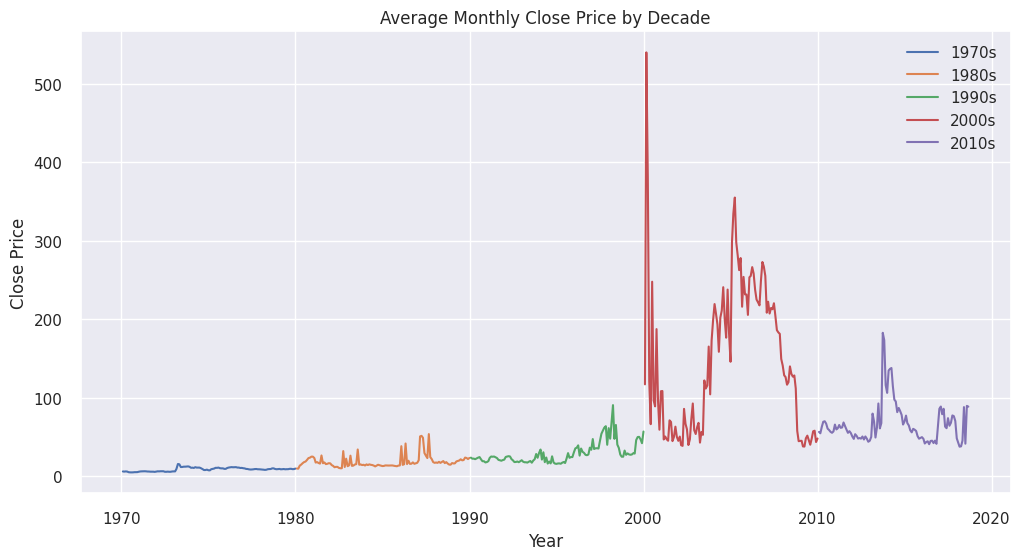

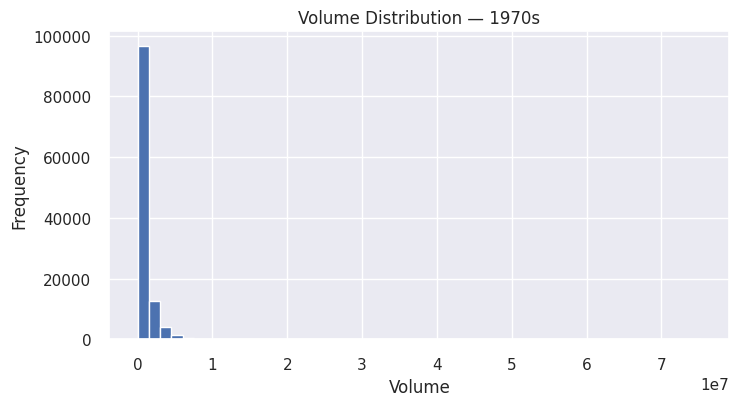

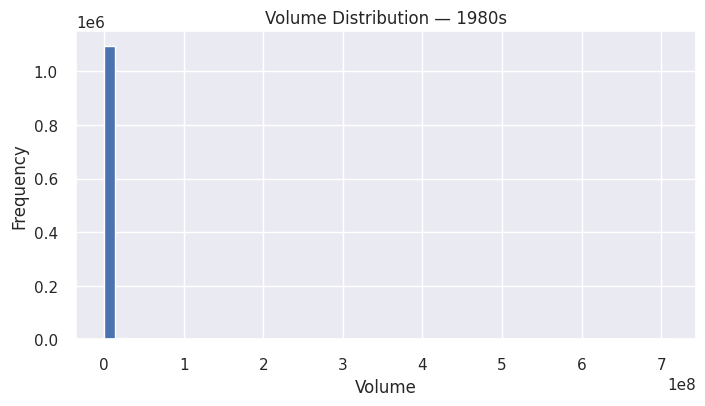

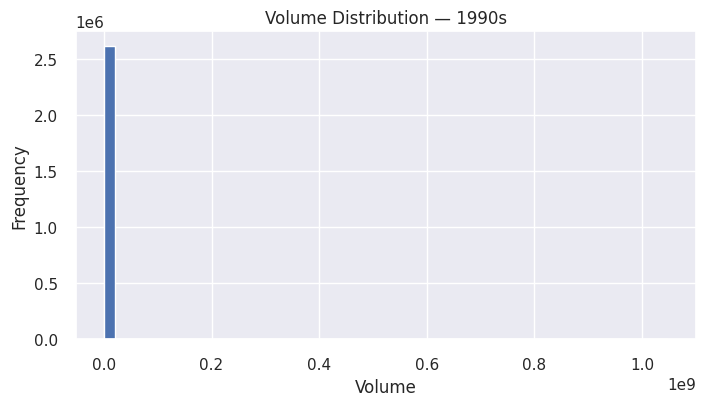

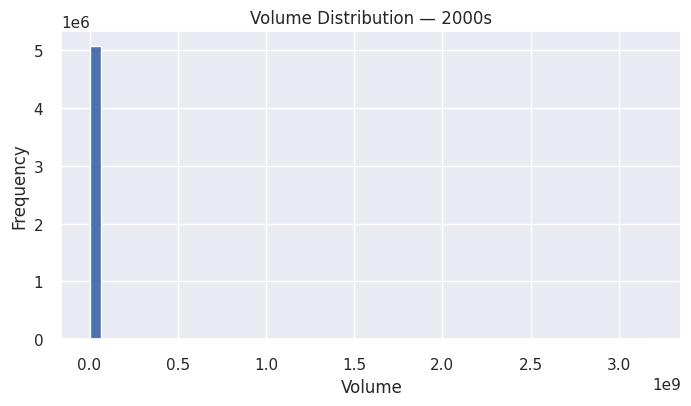

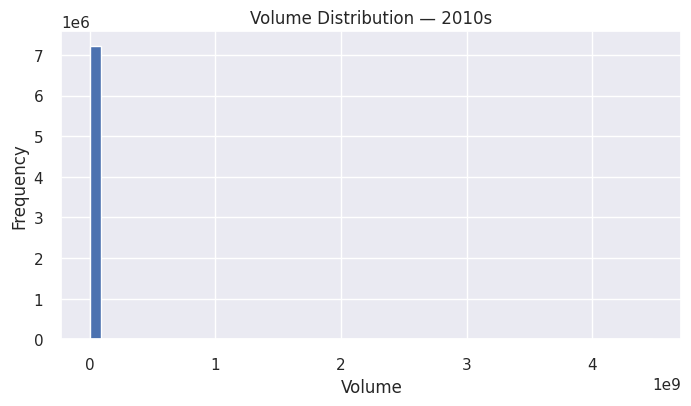

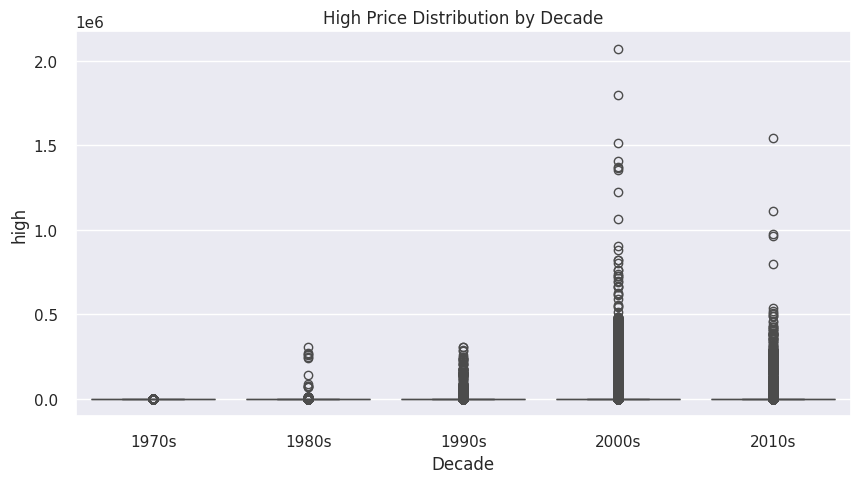

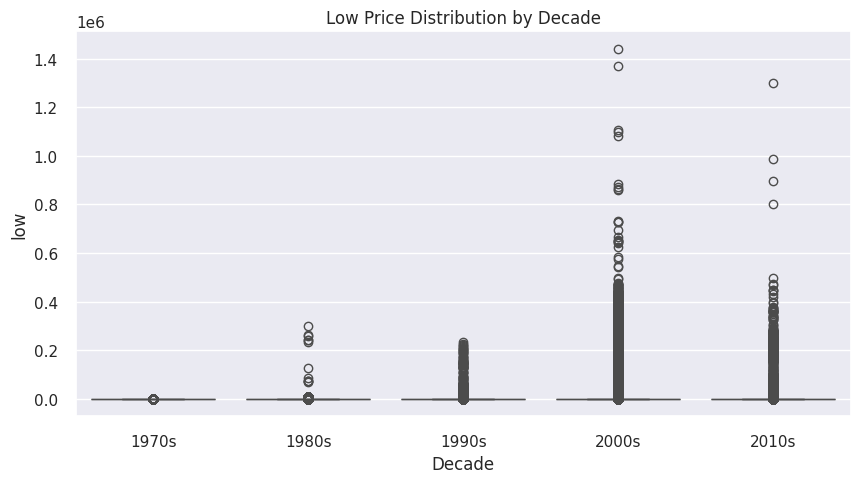


Mean Close & Volume by decade:
        Mean_Close   Mean_Volume
Decade                          
1970s     9.560198  7.806938e+05
1980s    19.413536  8.219392e+05
1990s    31.704225  8.375463e+05
2000s   147.477423  1.410735e+06
2010s    66.902765  1.371202e+06

===== 1970s =====
Rows: 115914
Close range: 0.015625 to 420.833343505859
Average volume: 780693.7660938281

===== 1980s =====
Rows: 1102673
Close range: 0.02734375 to 303750.0
Average volume: 821939.2446183048

===== 1990s =====
Rows: 2625921
Close range: 0.0240000002086163 to 262500.0
Average volume: 837546.3302437507

===== 2000s =====
Rows: 5074744
Close range: 0.0001999999949475 to 1779750.0
Average volume: 1410735.207274495

===== 2010s =====
Rows: 7221538
Close range: 0.0003000000142492 to 1347500.0
Average volume: 1371202.3765564898

Notebook complete. Use the tables and plots for your report.


In [3]:
# ============================================================
# 📌 HISTORICAL STOCKS EDA BY DECADE
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")
sns.set_theme()

# ============================================================
# 1. LOAD BOTH DATASETS
# ============================================================

# Reading the csv Files
stocks = pd.read_csv("historical_stocks.csv")
print("Stocks file loaded:")
print(stocks.head())

# Load the 2GB file in chunks
chunks = []
chunk_size = 500000

print("Loading historical_stock_prices.csv in chunks...")
for chunk in pd.read_csv("historical_stock_prices.csv", chunksize=chunk_size):
    chunks.append(chunk)

prices = pd.concat(chunks, ignore_index=True)
print("Prices file loaded:")
print(prices.head())

# ============================================================
# 2. CLEANING — USING REAL COLUMN NAMES
# ============================================================

# Check missing values
print("\nMissing values:")
print(prices.isnull().sum())

# Drop rows where core OHLC is missing
prices = prices.dropna(subset=["open", "high", "low", "close"])

# Interpolate volume if missing
if prices["volume"].isnull().sum() > 0:
    prices["volume"] = prices["volume"].interpolate()

# Convert date column
prices["date"] = pd.to_datetime(prices["date"])
prices = prices.set_index("date").sort_index()

# Remove duplicates
prices = prices.drop_duplicates()
stocks = stocks.drop_duplicates()

print("\nCleaned prices info:")
print(prices.info())

# ============================================================
# 3. ADD DECADE COLUMN
# ============================================================

prices["Decade"] = (prices.index.year // 10) * 10
prices["Decade"] = prices["Decade"].astype(str) + "s"

print("\nDecades found:", prices["Decade"].unique())

# Create decade DataFrames
decades = {dec: prices[prices["Decade"] == dec] for dec in prices["Decade"].unique()}

# ============================================================
# 4. MERGE WITH STOCK METADATA
# ============================================================

# Your metadata file uses "ticker"
merged = prices.reset_index().merge(stocks, on="ticker", how="left")
merged = merged.set_index("date").sort_index()

print("\nMerged sample:")
print(merged.head())

# ============================================================
# 5. SUMMARY STATISTICS BY DECADE
# ============================================================

summary = (
    merged
    .groupby("Decade")[["open", "high", "low", "close", "volume"]]
    .agg(["mean", "median", "std"])
)

print("\nSummary statistics by decade:")
print(summary)

# ============================================================
# 6. VISUALIZATIONS
# ============================================================

# 6.1 Average monthly close price
plt.figure(figsize=(12, 6))
for dec in sorted(decades.keys()):
    df_dec = decades[dec]
    monthly = df_dec["close"].resample("M").mean()
    plt.plot(monthly.index, monthly.values, label=dec)

plt.title("Average Monthly Close Price by Decade")
plt.xlabel("Year")
plt.ylabel("Close Price")
plt.legend()
plt.show()

# 6.2 Volume histograms
for dec in sorted(decades.keys()):
    plt.figure(figsize=(8, 4))
    decades[dec]["volume"].hist(bins=50)
    plt.title(f"Volume Distribution — {dec}")
    plt.xlabel("Volume")
    plt.ylabel("Frequency")
    plt.show()

# 6.3 Boxplots for high/low
plt.figure(figsize=(10, 5))
sns.boxplot(x="Decade", y="high", data=merged)
plt.title("High Price Distribution by Decade")
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(x="Decade", y="low", data=merged)
plt.title("Low Price Distribution by Decade")
plt.show()

# ============================================================
# 7. COMPARATIVE ANALYSIS HELPERS
# ============================================================

mean_close_volume = (
    merged.groupby("Decade")[["close", "volume"]]
    .mean()
    .rename(columns={"close": "Mean_Close", "volume": "Mean_Volume"})
)

print("\nMean Close & Volume by decade:")
print(mean_close_volume)

# ============================================================
# 8. PRINT BASIC INSIGHTS
# ============================================================

def describe_decade(dec):
    df = decades[dec]
    print(f"\n===== {dec} =====")
    print("Rows:", len(df))
    print("Close range:", df["close"].min(), "to", df["close"].max())
    print("Average volume:", df["volume"].mean())

for dec in sorted(decades.keys()):
    describe_decade(dec)

print("\nProject completed")